In [1]:
from USGSreportmaker import ReportMaker
from datetime import datetime


In [2]:
# tracemalloc.start()

rm = ReportMaker()

# current, peak = tracemalloc.get_traced_memory()
# print(f"Current memory usage: {current / 10**6} MB")
# print(f"Peak memory usage: {peak / 10**6} MB")

# tracemalloc.stop()

Fetched USGS data for query.


In [4]:
rm.evlist

[(0, 'M 3.5 - 16 km NW of Pinnacles, CA'),
 (1, 'M 3.4 - 47 km SE of Beatty, Nevada'),
 (2, 'M 3.6 - 0 km W of Angwin, CA'),
 (3, 'M 3.2 - 13 km NNE of Avalon, CA'),
 (4, 'M 3.2 - 2 km SE of Aromas, CA'),
 (5, 'M 3.0 - 17 km WSW of Johannesburg, CA'),
 (6, 'M 3.1 - 76 km SSE of Lamoille, Nevada'),
 (7, 'M 3.9 - 15 km NNE of Alder Springs, CA'),
 (8, 'M 3.4 - 12 km N of Ocotillo Wells, CA'),
 (9, 'M 3.3 - 17 km WSW of Johannesburg, CA'),
 (10, 'M 3.1 - 91 km SSW of Alberto Oviedo Mota, B.C., MX'),
 (11, 'M 3.0 - 4 km WSW of Johnsville, CA'),
 (12, 'M 3.2 - 18 km NNW of Indian Springs, Nevada'),
 (13, 'M 3.1 - 18 km W of Petrolia, CA'),
 (14, 'M 5.6 - 11 km N of Redwood Valley, CA'),
 (15, 'M 3.4 - 5 km SW of Ridgemark, CA'),
 (16, 'M 3.6 - 21 km N of Searles Valley, CA'),
 (17, 'M 3.2 - 1 km ENE of Huron, CA'),
 (18, 'M 4.1 - 179 km WSW of Port Orford, Oregon'),
 (19, 'M 3.0 - 33 km N of Benton, California'),
 (20, 'M 3.6 - 18 km WSW of Johannesburg, CA'),
 (21, 'M 3.1 - 8 km ESE of Clo

In [4]:
# tracemalloc.start()

index = 1000
rm_temp = ReportMaker() # new insance to avoid editing the auto-reports

rm_temp.load_ev_detail(index,is_temp=True)
rm_temp.get_eew_data()

# check if event happened before launch of ShakeAlert
tformat = "%b %d, %Y %I:%M %p"
SAlaunch = "Oct 1, 2019 12:00 AM"
before_SA = datetime.strptime(rm_temp.ev_timestamp,tformat) < datetime.strptime(SAlaunch,tformat)

if rm_temp.has_eew:
    rm_temp.make_eew_map(is_temp=True)
    msg1 = (
        f"This earthquake triggered ShakeAlert.\n"
        f"An alert was sent to the following regions/counties:\n"
        f"-{"\n-".join(rm_temp.formatted_warned_areas)}\n"
    )
    print(msg1)
elif before_SA:
    print("This earthquake occurred before the launch of ShakeAlert.")
else:
    print("This earthquake did not trigger ShakeAlert.")

rm_temp.make_mmi_map(is_temp=True)

if rm_temp.mmi_plottable:
    msg2 = (
        f"On {rm_temp.ev_timestamp}\n"
        f"{rm_temp.mmi_report_caption}\n"
        f"Magnitude: {rm_temp.ev_mag}\n"
        f"Maximum intensity: {rm_temp.ev_maxnumeral} ({rm_temp.ev_maxdesc})\n"
        f"Maximum intensity felt in the following cities:\n"
        f"-{"\n-".join(rm_temp.cities_max_mmi)}\n\n"
    )
    print(msg2)
else:
    msg2_alt = (
        f"On {rm_temp.ev_timestamp}\n"
        f"A magnitude {rm_temp.ev_mag} occurred in the region.\n"
        f"No intensity-by-city information is available to plot for this earthquake.\n"
        f"For more details visit {rm_temp.ev_url}"
    )
    print(msg2_alt)



# current, peak = tracemalloc.get_traced_memory()
# print(f"Current memory usage: {current / 10**6} MB")
# print(f"Peak memory usage: {peak / 10**6} MB")

# tracemalloc.stop()

Fetched USGS data for query.
Loading report:
M 3.4 - 17 km ENE of Walker Lake, Nevada
Aug 24, 2024 07:05 AM
Event has no ShakeAlert product.
This earthquake did not trigger ShakeAlert.
No losspager. Using dyfi txt
losspager and dyfi not available. Plot cannot be be made
On Aug 24, 2024 07:05 AM
A magnitude 3.4 occurred in the region.
No intensity-by-city information is available to plot for this earthquake.
For more details visit https://earthquake.usgs.gov/earthquakes/eventpage/nn00882938


In [ ]:
rm.load_ev_detail(1600,is_temp=True)
rm.get_eew_data()
rm.make_eew_map()

Loading report:
M 3.5 - 32 km SE of Mina, Nevada
Feb 22, 2023 10:22 AM
Event has no ShakeAlert product.
Event has no ShakeAlert product.
No EEW was issued for this event.


No losspager. Using dyfi txt
No losspager. Using dyfi txt


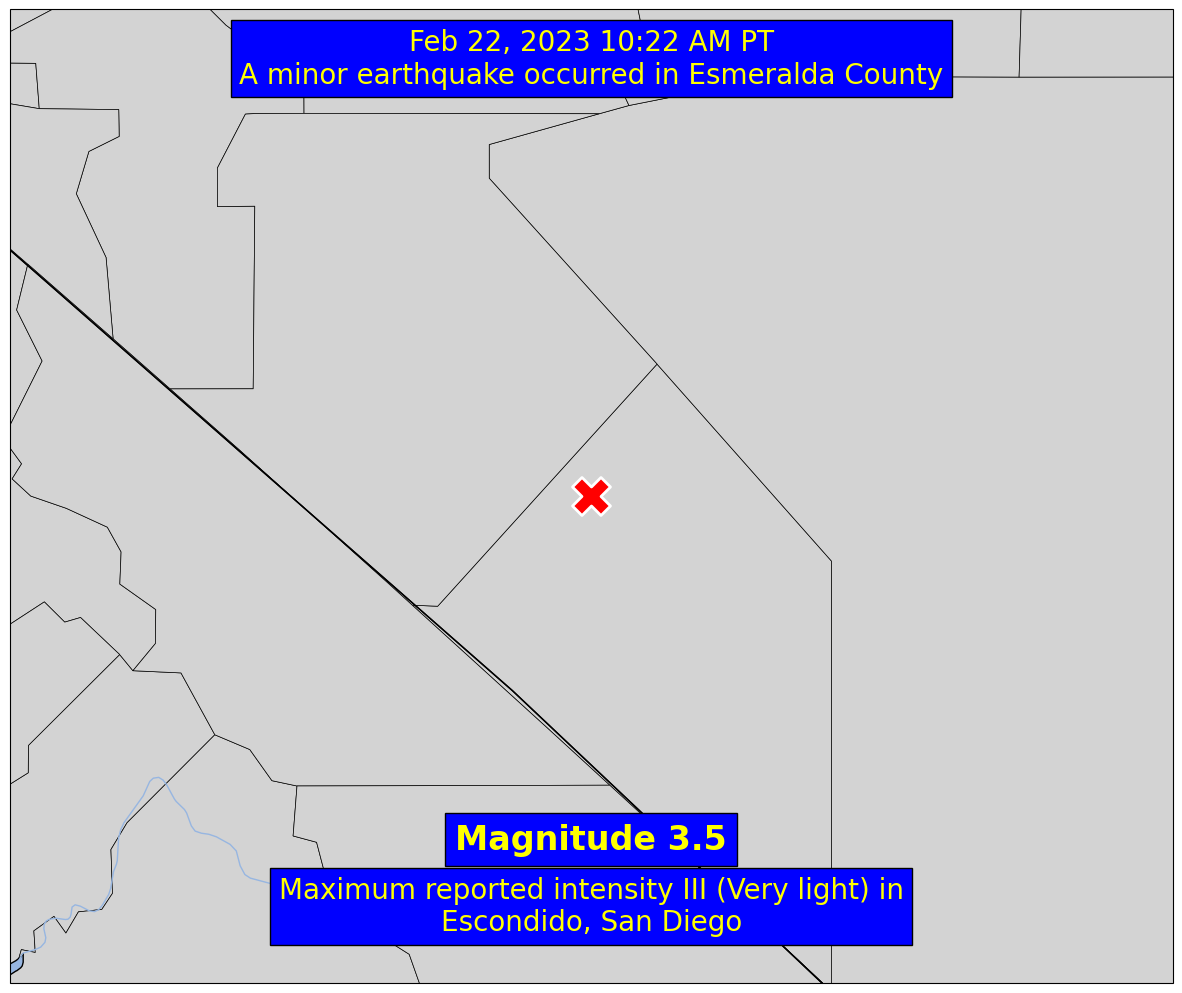

In [ ]:
rm.get_mmi_data()
rm.make_mmi_map()

In [ ]:
s = rm.ca_nv[rm.ca_nv['COUNTYFP'] == '049']['STATEFP'].iloc[0]
s

'06'

'06'